# Simpson's Paradox Investigation

Investigating why individual-level effects (fast contact → higher conversion) disappear at the location level.

**Three analyses:**
1. Control for lead characteristics by location
2. Within-location analysis: fast vs slow contact conversion rates
3. Lead mix comparison across high vs low converting locations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

In [2]:
# Load data (INCLUDING UNUSED_IND=1 records)
file_path = '../data/raw/Conversion Data Nov-Dec 2025 (1).xlsx'
df = pd.read_excel(file_path, engine='openpyxl')

# Clean column names
df.columns = df.columns.str.strip()

# Note: Including ALL records (UNUSED_IND=0 and UNUSED_IND=1)
unused_count = df['UNUSED_IND'].sum() if 'UNUSED_IND' in df.columns else 0
print(f"Total records: {len(df):,}")
print(f"  - UNUSED_IND=1: {unused_count:,} ({unused_count/len(df)*100:.1f}%)")
print(f"  - UNUSED_IND=0: {len(df)-unused_count:,} ({(len(df)-unused_count)/len(df)*100:.1f}%)")
print(f"\nColumns available: {list(df.columns)}")

Total records: 68,360
  - UNUSED_IND=1: 13,301 (19.5%)
  - UNUSED_IND=0: 55,059 (80.5%)

Columns available: ['CONFIRM_NUM', 'RENTER_LAST', 'CLAIM', 'CDP', 'CDP NAME', 'Week Of', 'INIT_DATE', '4 loC', 'HTZREGION', 'SET_STATE', 'ZONE', 'AREA_MGR', 'GENERAL_MGR', 'RENT_LOC', 'RES_ID', 'RENT_IND', 'CANCEL_ID', 'UNUSED_IND', 'CONTACT_GROUP', 'New Contact Group', 'CONTACT RANGE', 'ADJ LNAME', 'ADJ FNAME', 'BODY SHOP', 'CODE', 'KNUM', 'MONTH', 'ZIP', 'CANCEL REASON', 'INIT_DT_FINAL', 'DT_FROM_ALPHA1', 'DAY_DIF', 'HRS_DIF', 'MIN_DIF', 'MMR']


In [3]:
# Quick look at key columns
print("Data types:")
print(df.dtypes)
print("\n" + "="*50)
print("\nSample data:")
df.head()

Data types:
CONFIRM_NUM                  object
RENTER_LAST                  object
CLAIM                        object
CDP                          object
CDP NAME                     object
Week Of              datetime64[ns]
INIT_DATE            datetime64[ns]
4 loC                       float64
HTZREGION                    object
SET_STATE                    object
ZONE                         object
AREA_MGR                     object
GENERAL_MGR                  object
RENT_LOC                     object
RES_ID                        int64
RENT_IND                      int64
CANCEL_ID                     int64
UNUSED_IND                    int64
CONTACT_GROUP                object
New Contact Group            object
CONTACT RANGE                object
ADJ LNAME                    object
ADJ FNAME                    object
BODY SHOP                    object
CODE                         object
KNUM                         object
MONTH                         int64
ZIP             

,CONFIRM_NUM,RENTER_LAST,CLAIM,CDP,CDP NAME,Week Of,INIT_DATE,4 loC,HTZREGION,SET_STATE,ZONE,AREA_MGR,GENERAL_MGR,RENT_LOC,RES_ID,RENT_IND,CANCEL_ID,UNUSED_IND,CONTACT_GROUP,New Contact Group,CONTACT RANGE,ADJ LNAME,ADJ FNAME,BODY SHOP,CODE,KNUM,MONTH,ZIP,CANCEL REASON,INIT_DT_FINAL,DT_FROM_ALPHA1,DAY_DIF,HRS_DIF,MIN_DIF,MMR
0,242-9890118,ROBINSON,115845,1856933,MULLINAX FORD OF OSCEOLA,2025-11-10,2025-11-13,NaN,LICENSEE,AL,LICENSEE,NaN,TONY FULLER,96260-02 - DOTHAN HLE,1,1,0,0,NO CONTACT,NO CONTACT,NO CONTACT,,GAINES TAYLOR,,0,N11491616,202511,36303,,2025-11-13 07:48:00,NaT,NaN,NaN,NaN,NO MMR
1,037-9938451,BETTINGFIELD,161742,0,,2025-11-10,2025-11-14,NaN,EASTERN,GA,SE,KINGSLEY EVANS,TODD STARBUCK,4900-01 - BUFORD HLE,1,0,1,0,NO CONTACT,NO CONTACT,NO CONTACT,,Hagi Kira,MALL OF GEORGIA CHRYSLER JEEP DODGE,0,037-9938451,202511,30518,NO SHOW,2025-11-14 08:30:00,NaT,NaN,NaN,NaN,NO MMR
2,037-9911253,PERRY,300-0674073-2025-PD-11,0,,2025-11-03,2025-11-04,NaN,EASTERN,GA,SE,OMAR CARTER,TODD STARBUCK,5624-01 - CONYERS HLE,1,0,0,1,COUNTER,COUNTER,(a)<30min,,MOEN CALLI,GINN CHRYSLER JEEP DODGE,0,037-9911253,202511,30012,,2025-11-04 08:46:00,2025-11-04 08:58:00,0.0,0.0,12.0,NO MMR
3,037-9965736,JACKACKI,827423GQ,0,,2025-11-24,2025-11-25,NaN,CENTRAL,OH,NC,BRANDON TUTOR,JUSTIN BRIETZKE,5464-01 - BEDFORD HEIGHTS HLE,1,0,0,1,NO CONTACT,NO CONTACT,NO CONTACT,,Lacks Amanda,,0,037-9965736,202511,44146,,2025-11-25 11:02:00,NaT,NaN,NaN,NaN,NO MMR
4,037-9928472,JONES,300-0662001-2025,0,,2025-11-10,2025-11-10,NaN,EASTERN,SC,MA,TREY JONES,SCOTT MILLER,6852-01 - ROCK HILL HLE,1,0,1,0,COUNTER,COUNTER,(a)<30min,,TAYLOR ROBERT,,0,037-9928472,202511,29730,,2025-11-10 17:04:00,2025-11-10 17:05:00,0.0,0.0,1.0,NO MMR


---
## Analysis 1: Control for Lead Characteristics by Location

Check if certain locations receive systematically different types of leads.

In [4]:
# Identify categorical columns that might represent lead characteristics
potential_lead_chars = []
for col in df.columns:
    if df[col].dtype == 'object' or df[col].nunique() < 20:
        if col not in ['RENT_LOC', 'RES_ID', 'RENT_IND', 'CONTACT RANGE', 'CONTACT_GROUP']:
            potential_lead_chars.append(col)

print("Potential lead characteristic columns:")
for col in potential_lead_chars:
    print(f"  {col}: {df[col].nunique()} unique values")

Potential lead characteristic columns:
  CONFIRM_NUM: 68360 unique values
  RENTER_LAST: 30087 unique values
  CLAIM: 66900 unique values
  CDP: 654 unique values
  CDP NAME: 644 unique values
  Week Of: 9 unique values
  4 loC: 0 unique values
  HTZREGION: 5 unique values
  SET_STATE: 61 unique values
  ZONE: 24 unique values
  AREA_MGR: 143 unique values
  GENERAL_MGR: 159 unique values
  CANCEL_ID: 2 unique values
  UNUSED_IND: 2 unique values
  New Contact Group: 3 unique values
  ADJ LNAME: 1 unique values
  ADJ FNAME: 12989 unique values
  BODY SHOP: 15537 unique values
  CODE: 24 unique values
  KNUM: 68339 unique values
  MONTH: 2 unique values
  ZIP: 1059 unique values
  CANCEL REASON: 14 unique values
  MMR: 2 unique values


In [5]:
# Calculate location-level metrics
location_stats = df.groupby('RENT_LOC').agg(
    total_reservations=('RES_ID', 'sum'),
    conversions=('RENT_IND', 'sum'),
    total_records=('RES_ID', 'count')
).reset_index()

location_stats['conversion_rate'] = (location_stats['conversions'] / location_stats['total_reservations'] * 100)

# Filter to locations with meaningful volume
location_stats = location_stats[location_stats['total_reservations'] >= 50].copy()

# Classify locations as high or low converting
median_conv = location_stats['conversion_rate'].median()
location_stats['conv_group'] = np.where(location_stats['conversion_rate'] >= median_conv, 'High Converting', 'Low Converting')

print(f"Median conversion rate: {median_conv:.1f}%")
print(f"High converting locations: {(location_stats['conv_group'] == 'High Converting').sum()}")
print(f"Low converting locations: {(location_stats['conv_group'] == 'Low Converting').sum()}")

Median conversion rate: 62.3%
High converting locations: 301
Low converting locations: 301


In [6]:
# Merge location classification back to main data
df_with_loc_class = df.merge(
    location_stats[['RENT_LOC', 'conv_group', 'conversion_rate']], 
    on='RENT_LOC', 
    how='inner'
)

print(f"Records after merge: {len(df_with_loc_class):,}")

Records after merge: 57,525


In [7]:
# Compare lead characteristics between high and low converting locations
print("="*60)
print("LEAD CHARACTERISTICS: High vs Low Converting Locations")
print("="*60)

# Check contact speed distribution
print("\n1. CONTACT SPEED DISTRIBUTION:")
contact_by_group = pd.crosstab(
    df_with_loc_class['conv_group'], 
    df_with_loc_class['CONTACT RANGE'], 
    normalize='index'
) * 100
print(contact_by_group.round(1))

print("\n2. CONTACT GROUP DISTRIBUTION:")
contact_group_by_conv = pd.crosstab(
    df_with_loc_class['conv_group'], 
    df_with_loc_class['CONTACT_GROUP'], 
    normalize='index'
) * 100
print(contact_group_by_conv.round(1))

LEAD CHARACTERISTICS: High vs Low Converting Locations

1. CONTACT SPEED DISTRIBUTION:
CONTACT RANGE    (a)<30min  (b)31min - 1hr  (c)1-3 hrs  (d)3-6 hrs  \
conv_group                                                           
High Converting       29.2            27.2        17.8         3.4   
Low Converting        25.8            26.0        18.6         3.9   

CONTACT RANGE    (e)6-12 hrs  (f)12-24 hrs  (g)24-48 hrs  (h)48+ hrs  \
conv_group                                                             
High Converting          2.2           8.6           1.9         0.7   
Low Converting           2.4          11.3           2.7         1.2   

CONTACT RANGE    NO CONTACT  
conv_group                   
High Converting         9.0  
Low Converting          8.1  

2. CONTACT GROUP DISTRIBUTION:
CONTACT_GROUP    COUNTER  HRD - OKC  NO CONTACT
conv_group                                     
High Converting     54.8       36.2         9.0
Low Converting      51.8       40.1         8.1

In [8]:
# Check other lead characteristics if available
char_cols_to_check = [col for col in potential_lead_chars if col in df.columns and df[col].nunique() <= 10]

for col in char_cols_to_check[:5]:  # Check top 5 categorical variables
    print(f"\n{col.upper()} DISTRIBUTION:")
    try:
        crosstab = pd.crosstab(
            df_with_loc_class['conv_group'], 
            df_with_loc_class[col], 
            normalize='index'
        ) * 100
        print(crosstab.round(1))
    except:
        print(f"  Could not analyze {col}")


WEEK OF DISTRIBUTION:
Week Of          2025-11-03  2025-11-10  2025-11-17  2025-11-24  2025-12-01  \
conv_group                                                                    
High Converting        12.8        13.3        12.8         9.1        13.1   
Low Converting         12.1        12.5        12.7         8.7        13.2   

Week Of          2025-12-08  2025-12-15  2025-12-22  2025-12-29  
conv_group                                                       
High Converting        12.6        11.9         7.7         6.7  
Low Converting         13.0        12.4         8.2         7.1  

4 LOC DISTRIBUTION:
Empty DataFrame
Columns: []
Index: []

HTZREGION DISTRIBUTION:
HTZREGION        CANADA  CENTRAL  EASTERN  LICENSEE  WESTERN
conv_group                                                  
High Converting     0.0     36.1     45.8       5.6     12.5
Low Converting      1.7     33.2     39.7       2.0     23.3

CANCEL_ID DISTRIBUTION:
CANCEL_ID           0     1
conv_group     

---
## Analysis 2: Within-Location Analysis

For each location, compare conversion rates of fast vs slow contacted leads. This controls for location-level confounders.

In [9]:
# Create fast contact indicator
df['fast_contact'] = (df['CONTACT RANGE'] == '(a)<30min').astype(int)
df['counter_contact'] = (df['CONTACT_GROUP'] == 'COUNTER').astype(int)

# Calculate within-location conversion rates by contact speed
within_loc_analysis = df.groupby(['RENT_LOC', 'fast_contact']).agg(
    reservations=('RES_ID', 'sum'),
    conversions=('RENT_IND', 'sum')
).reset_index()

within_loc_analysis['conv_rate'] = within_loc_analysis['conversions'] / within_loc_analysis['reservations'] * 100

# Pivot to compare fast vs slow within each location
within_loc_pivot = within_loc_analysis.pivot(
    index='RENT_LOC', 
    columns='fast_contact', 
    values=['conv_rate', 'reservations']
)

within_loc_pivot.columns = ['conv_slow', 'conv_fast', 'n_slow', 'n_fast']
within_loc_pivot = within_loc_pivot.dropna()

# Filter to locations with at least 10 in each group
within_loc_pivot = within_loc_pivot[(within_loc_pivot['n_slow'] >= 10) & (within_loc_pivot['n_fast'] >= 10)].copy()

# Calculate the lift from fast contact
within_loc_pivot['fast_contact_lift'] = within_loc_pivot['conv_fast'] - within_loc_pivot['conv_slow']

print(f"Locations with sufficient data in both groups: {len(within_loc_pivot)}")

Locations with sufficient data in both groups: 625


In [10]:
# Summary statistics of within-location lift
print("WITHIN-LOCATION FAST CONTACT LIFT (percentage points):")
print(f"  Mean lift: {within_loc_pivot['fast_contact_lift'].mean():.1f} pp")
print(f"  Median lift: {within_loc_pivot['fast_contact_lift'].median():.1f} pp")
print(f"  Std dev: {within_loc_pivot['fast_contact_lift'].std():.1f} pp")
print(f"  Min: {within_loc_pivot['fast_contact_lift'].min():.1f} pp")
print(f"  Max: {within_loc_pivot['fast_contact_lift'].max():.1f} pp")
print(f"\n  Locations where fast contact helps: {(within_loc_pivot['fast_contact_lift'] > 0).sum()} ({(within_loc_pivot['fast_contact_lift'] > 0).mean()*100:.0f}%)")
print(f"  Locations where fast contact hurts: {(within_loc_pivot['fast_contact_lift'] < 0).sum()} ({(within_loc_pivot['fast_contact_lift'] < 0).mean()*100:.0f}%)")

WITHIN-LOCATION FAST CONTACT LIFT (percentage points):
  Mean lift: 14.5 pp
  Median lift: 14.2 pp
  Std dev: 12.7 pp
  Min: -27.2 pp
  Max: 54.8 pp

  Locations where fast contact helps: 546 (87%)
  Locations where fast contact hurts: 78 (12%)


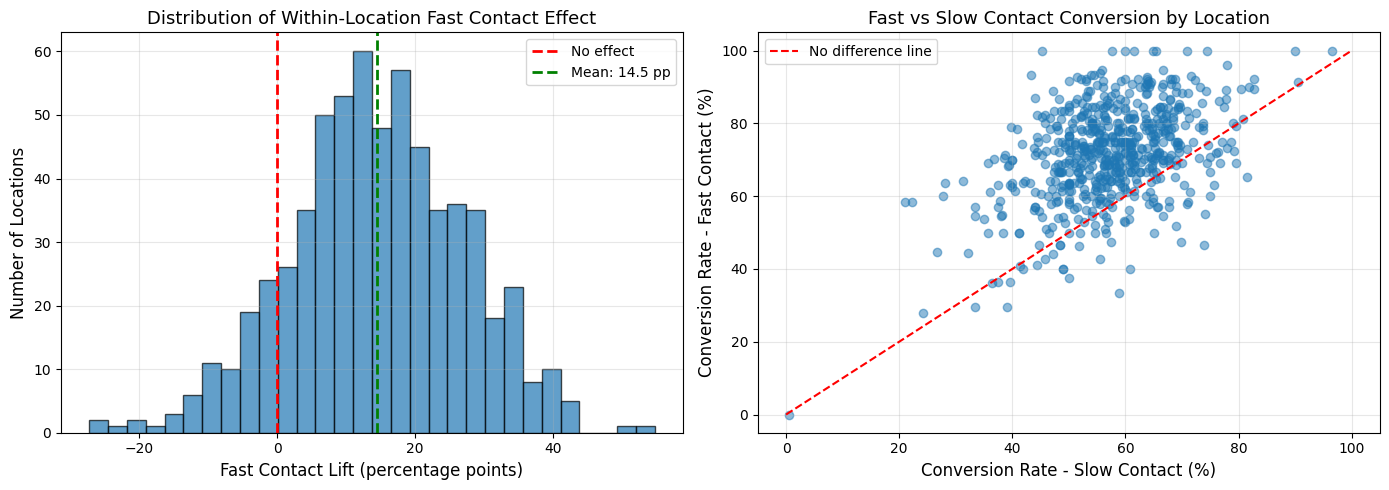

In [11]:
# Visualize the within-location lift distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of lift
axes[0].hist(within_loc_pivot['fast_contact_lift'], bins=30, edgecolor='black', alpha=0.7)
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2, label='No effect')
axes[0].axvline(x=within_loc_pivot['fast_contact_lift'].mean(), color='green', linestyle='--', linewidth=2, label=f'Mean: {within_loc_pivot["fast_contact_lift"].mean():.1f} pp')
axes[0].set_xlabel('Fast Contact Lift (percentage points)', fontsize=12)
axes[0].set_ylabel('Number of Locations', fontsize=12)
axes[0].set_title('Distribution of Within-Location Fast Contact Effect', fontsize=13)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Scatter: slow vs fast conversion rates
axes[1].scatter(within_loc_pivot['conv_slow'], within_loc_pivot['conv_fast'], alpha=0.5)
axes[1].plot([0, 100], [0, 100], 'r--', label='No difference line')
axes[1].set_xlabel('Conversion Rate - Slow Contact (%)', fontsize=12)
axes[1].set_ylabel('Conversion Rate - Fast Contact (%)', fontsize=12)
axes[1].set_title('Fast vs Slow Contact Conversion by Location', fontsize=13)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
# Same analysis for Counter contact
within_loc_counter = df.groupby(['RENT_LOC', 'counter_contact']).agg(
    reservations=('RES_ID', 'sum'),
    conversions=('RENT_IND', 'sum')
).reset_index()

within_loc_counter['conv_rate'] = within_loc_counter['conversions'] / within_loc_counter['reservations'] * 100

within_loc_counter_pivot = within_loc_counter.pivot(
    index='RENT_LOC', 
    columns='counter_contact', 
    values=['conv_rate', 'reservations']
)

within_loc_counter_pivot.columns = ['conv_non_counter', 'conv_counter', 'n_non_counter', 'n_counter']
within_loc_counter_pivot = within_loc_counter_pivot.dropna()
within_loc_counter_pivot = within_loc_counter_pivot[(within_loc_counter_pivot['n_non_counter'] >= 10) & (within_loc_counter_pivot['n_counter'] >= 10)].copy()
within_loc_counter_pivot['counter_lift'] = within_loc_counter_pivot['conv_counter'] - within_loc_counter_pivot['conv_non_counter']

print("WITHIN-LOCATION COUNTER CONTACT LIFT (percentage points):")
print(f"  Mean lift: {within_loc_counter_pivot['counter_lift'].mean():.1f} pp")
print(f"  Median lift: {within_loc_counter_pivot['counter_lift'].median():.1f} pp")
print(f"  Locations where counter helps: {(within_loc_counter_pivot['counter_lift'] > 0).sum()} ({(within_loc_counter_pivot['counter_lift'] > 0).mean()*100:.0f}%)")

WITHIN-LOCATION COUNTER CONTACT LIFT (percentage points):
  Mean lift: 23.4 pp
  Median lift: 23.1 pp
  Locations where counter helps: 662 (94%)


---
## Analysis 3: Lead Mix Comparison

Compare the composition of leads at high-converting vs low-converting locations.

In [13]:
# Aggregate lead mix metrics by location
location_mix = df.groupby('RENT_LOC').agg(
    total_reservations=('RES_ID', 'sum'),
    conversions=('RENT_IND', 'sum'),
    pct_fast_contact=('fast_contact', 'mean'),
    pct_counter=('counter_contact', 'mean'),
    pct_no_contact=('CONTACT RANGE', lambda x: (x == 'NO CONTACT').mean())
).reset_index()

location_mix['conversion_rate'] = location_mix['conversions'] / location_mix['total_reservations'] * 100
location_mix['pct_fast_contact'] *= 100
location_mix['pct_counter'] *= 100
location_mix['pct_no_contact'] *= 100

# Filter to meaningful volume
location_mix = location_mix[location_mix['total_reservations'] >= 50].copy()

# Classify
median_conv = location_mix['conversion_rate'].median()
location_mix['conv_group'] = np.where(location_mix['conversion_rate'] >= median_conv, 'High Converting', 'Low Converting')

location_mix.head()

,RENT_LOC,total_reservations,conversions,pct_fast_contact,pct_counter,pct_no_contact,conversion_rate,conv_group
0,- OKC RENTAL CONTROL UNIT,442,2,10.633484,11.312217,40.271493,0.452489,Low Converting
1,1185-18 - NEWPORT BEACH HLE,60,36,20.000000,75.000000,3.333333,60.000000,Low Converting
3,1507-01 - VETERANS AIRPORT HLE,83,41,55.421687,77.108434,2.409639,49.397590,Low Converting
5,1545-17 - AKRON/CANTON AP,53,32,9.433962,32.075472,1.886792,60.377358,Low Converting
6,1611-01 - MUNICIPAL AP,69,49,42.028986,68.115942,2.898551,71.014493,High Converting


In [14]:
# Compare metrics between high and low converting locations
comparison = location_mix.groupby('conv_group').agg({
    'conversion_rate': ['mean', 'std'],
    'pct_fast_contact': ['mean', 'std'],
    'pct_counter': ['mean', 'std'],
    'pct_no_contact': ['mean', 'std'],
    'total_reservations': ['mean', 'sum']
}).round(1)

print("COMPARISON: High vs Low Converting Locations")
print("="*60)
print(comparison)

COMPARISON: High vs Low Converting Locations
                conversion_rate      pct_fast_contact       pct_counter        \
                           mean  std             mean   std        mean   std   
conv_group                                                                      
High Converting            68.8  5.8             28.9  14.3        54.0  19.6   
Low Converting             54.6  8.3             26.2  12.4        53.0  18.7   

                pct_no_contact       total_reservations         
                          mean   std               mean    sum  
conv_group                                                      
High Converting           10.1  24.0               92.2  27750  
Low Converting             7.6  14.8               98.9  29775  


In [15]:
# Statistical test: Do high-converting locations have different contact patterns?
from scipy import stats

high_conv = location_mix[location_mix['conv_group'] == 'High Converting']
low_conv = location_mix[location_mix['conv_group'] == 'Low Converting']

print("T-TEST RESULTS: High vs Low Converting Locations")
print("="*60)

for metric in ['pct_fast_contact', 'pct_counter', 'pct_no_contact']:
    t_stat, p_val = stats.ttest_ind(high_conv[metric], low_conv[metric])
    high_mean = high_conv[metric].mean()
    low_mean = low_conv[metric].mean()
    diff = high_mean - low_mean
    sig = "*" if p_val < 0.05 else ""
    print(f"\n{metric}:")
    print(f"  High conv locations: {high_mean:.1f}%")
    print(f"  Low conv locations:  {low_mean:.1f}%")
    print(f"  Difference: {diff:+.1f} pp (p={p_val:.3f}) {sig}")

T-TEST RESULTS: High vs Low Converting Locations

pct_fast_contact:
  High conv locations: 28.9%
  Low conv locations:  26.2%
  Difference: +2.7 pp (p=0.012) *

pct_counter:
  High conv locations: 54.0%
  Low conv locations:  53.0%
  Difference: +1.0 pp (p=0.530) 

pct_no_contact:
  High conv locations: 10.1%
  Low conv locations:  7.6%
  Difference: +2.5 pp (p=0.125) 


/var/folders/x0/6cfvvvlj3g7fwgfj3fwm8zgh0000gn/T/ipykernel_39722/2172695029.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[2].boxplot(data_to_plot, labels=['High Converting', 'Low Converting'], patch_artist=True)


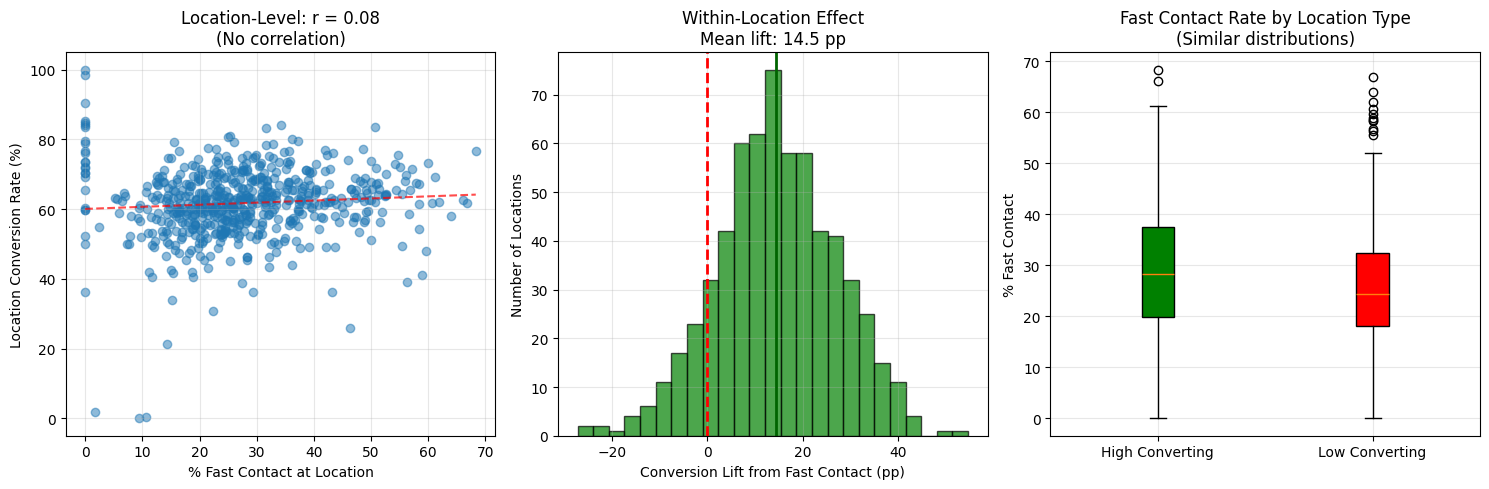

In [16]:
# Visualize the paradox
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Location-level correlation (no relationship)
axes[0].scatter(location_mix['pct_fast_contact'], location_mix['conversion_rate'], alpha=0.5)
z = np.polyfit(location_mix['pct_fast_contact'], location_mix['conversion_rate'], 1)
p = np.poly1d(z)
x_line = np.linspace(location_mix['pct_fast_contact'].min(), location_mix['pct_fast_contact'].max(), 100)
axes[0].plot(x_line, p(x_line), 'r--', alpha=0.7)
corr = location_mix['pct_fast_contact'].corr(location_mix['conversion_rate'])
axes[0].set_xlabel('% Fast Contact at Location')
axes[0].set_ylabel('Location Conversion Rate (%)')
axes[0].set_title(f'Location-Level: r = {corr:.2f}\n(No correlation)')
axes[0].grid(True, alpha=0.3)

# Plot 2: Within-location effect (strong relationship)
axes[1].hist(within_loc_pivot['fast_contact_lift'], bins=25, edgecolor='black', alpha=0.7, color='green')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1].axvline(x=within_loc_pivot['fast_contact_lift'].mean(), color='darkgreen', linestyle='-', linewidth=2)
axes[1].set_xlabel('Conversion Lift from Fast Contact (pp)')
axes[1].set_ylabel('Number of Locations')
axes[1].set_title(f'Within-Location Effect\nMean lift: {within_loc_pivot["fast_contact_lift"].mean():.1f} pp')
axes[1].grid(True, alpha=0.3)

# Plot 3: Box plot comparison
data_to_plot = [high_conv['pct_fast_contact'], low_conv['pct_fast_contact']]
bp = axes[2].boxplot(data_to_plot, labels=['High Converting', 'Low Converting'], patch_artist=True)
bp['boxes'][0].set_facecolor('green')
bp['boxes'][1].set_facecolor('red')
axes[2].set_ylabel('% Fast Contact')
axes[2].set_title('Fast Contact Rate by Location Type\n(Similar distributions)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Summary & Key Findings

In [17]:
print("="*70)
print("SIMPSON'S PARADOX INVESTIGATION: SUMMARY")
print("="*70)

print("\n1. INDIVIDUAL-LEVEL EFFECT (Within-Location Analysis):")
print(f"   - Fast contact provides {within_loc_pivot['fast_contact_lift'].mean():.1f} pp lift on average")
print(f"   - Effect is positive in {(within_loc_pivot['fast_contact_lift'] > 0).mean()*100:.0f}% of locations")
print(f"   - Counter contact provides {within_loc_counter_pivot['counter_lift'].mean():.1f} pp lift on average")

print("\n2. LOCATION-LEVEL CORRELATION:")
corr_fast = location_mix['pct_fast_contact'].corr(location_mix['conversion_rate'])
corr_counter = location_mix['pct_counter'].corr(location_mix['conversion_rate'])
print(f"   - % Fast Contact vs Conversion Rate: r = {corr_fast:.3f}")
print(f"   - % Counter vs Conversion Rate: r = {corr_counter:.3f}")

print("\n3. WHY THE PARADOX EXISTS:")
print("   - High and low converting locations have SIMILAR contact patterns")
print("   - Location conversion is driven by OTHER factors (lead quality, market, etc.)")
print("   - Fast contact helps WITHIN each location, but doesn't explain")
print("     BETWEEN-location differences")

print("\n4. IMPLICATION:")
print("   - Contact speed DOES matter for conversion (individual effect is real)")
print("   - But it's not the PRIMARY driver of location-level differences")
print("   - Other factors (unmeasured) explain why some locations convert better")

SIMPSON'S PARADOX INVESTIGATION: SUMMARY

1. INDIVIDUAL-LEVEL EFFECT (Within-Location Analysis):
   - Fast contact provides 14.5 pp lift on average
   - Effect is positive in 87% of locations
   - Counter contact provides 23.4 pp lift on average

2. LOCATION-LEVEL CORRELATION:
   - % Fast Contact vs Conversion Rate: r = 0.080
   - % Counter vs Conversion Rate: r = -0.028

3. WHY THE PARADOX EXISTS:
   - High and low converting locations have SIMILAR contact patterns
   - Location conversion is driven by OTHER factors (lead quality, market, etc.)
   - Fast contact helps WITHIN each location, but doesn't explain
     BETWEEN-location differences

4. IMPLICATION:
   - Contact speed DOES matter for conversion (individual effect is real)
   - But it's not the PRIMARY driver of location-level differences
   - Other factors (unmeasured) explain why some locations convert better
